In [21]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import re
import time

path_templates = Path("../../filter/templates_large_pulses/")

templates_ch_1010_charge = np.trapz(np.loadtxt(path_templates / "template_42228_C1_1.txt"))
templates_ch_1011_charge = np.trapz(np.loadtxt(path_templates / "template_42228_C1_2.txt"))
templates_ch_1020_charge = np.trapz(np.loadtxt(path_templates / "template_41519_C2_1.txt"))
templates_ch_1021_charge = np.trapz(np.loadtxt(path_templates / "template_41519_C2_2.txt"))
templates_ch_1030_charge = np.trapz(np.loadtxt(path_templates / "template_41536_C3_1.txt"))
templates_ch_1031_charge = np.trapz(np.loadtxt(path_templates / "template_41536_C3_2.txt"))
templates_ch_1040_charge = np.trapz(np.loadtxt(path_templates / "template_42067_C4_1.txt"))
templates_ch_1041_charge = np.trapz(np.loadtxt(path_templates / "template_42067_C4_2.txt"))
templates_ch_1050_charge = np.trapz(np.loadtxt(path_templates / "template_42228_C5_1.txt"))
templates_ch_1051_charge = np.trapz(np.loadtxt(path_templates / "template_42228_C5_2.txt"))
templates_ch_1060_charge = np.trapz(np.loadtxt(path_templates / "template_40807_C6_1.txt"))
templates_ch_1061_charge = np.trapz(np.loadtxt(path_templates / "template_40807_C6_2.txt"))
templates_ch_1070_charge = np.trapz(np.loadtxt(path_templates / "template_40808_C7_1.txt"))
templates_ch_1071_charge = np.trapz(np.loadtxt(path_templates / "template_40808_C7_2.txt"))
templates_ch_1080_charge = np.trapz(np.loadtxt(path_templates / "template_40808_C8_1.txt"))
templates_ch_1081_charge = np.trapz(np.loadtxt(path_templates / "template_40808_C8_2.txt"))

templates_ch_2010_charge = np.trapz(np.loadtxt(path_templates / "template_42379_M1_1.txt"))
templates_ch_2011_charge = np.trapz(np.loadtxt(path_templates / "template_42379_M1_2.txt"))
# Não existe template M2_1 para o canal 2020.
templates_ch_2021_charge = np.trapz(np.loadtxt(path_templates / "template_42379_M2_2.txt"))
templates_ch_2030_charge = np.trapz(np.loadtxt(path_templates / "template_40801_M3_1.txt"))
templates_ch_2031_charge = np.trapz(np.loadtxt(path_templates / "template_40801_M3_2.txt"))
templates_ch_2040_charge = np.trapz(np.loadtxt(path_templates / "template_40989_M4_1.txt"))
templates_ch_2041_charge = np.trapz(np.loadtxt(path_templates / "template_40989_M4_2.txt"))
templates_ch_2050_charge = np.trapz(np.loadtxt(path_templates / "template_42320_M5_1.txt"))
templates_ch_2051_charge = np.trapz(np.loadtxt(path_templates / "template_42320_M5_2.txt"))
templates_ch_2060_charge = np.trapz(np.loadtxt(path_templates / "template_40808_M6_1.txt"))
templates_ch_2061_charge = np.trapz(np.loadtxt(path_templates / "template_40808_M6_2.txt"))
templates_ch_2070_charge = np.trapz(np.loadtxt(path_templates / "template_43229_M7_1.txt"))
templates_ch_2071_charge = np.trapz(np.loadtxt(path_templates / "template_43229_M7_2.txt"))
templates_ch_2080_charge = np.trapz(np.loadtxt(path_templates / "template_42321_M8_1.txt"))
templates_ch_2081_charge = np.trapz(np.loadtxt(path_templates / "template_42321_M8_2.txt"))


list_templates_charge = {
    1010: templates_ch_1010_charge,
    1011: templates_ch_1011_charge,
    1020: templates_ch_1020_charge,
    1021: templates_ch_1021_charge,
    1030: templates_ch_1030_charge,
    1031: templates_ch_1031_charge,
    1040: templates_ch_1040_charge,
    1041: templates_ch_1041_charge,
    1050: templates_ch_1050_charge,
    1051: templates_ch_1051_charge,
    1060: templates_ch_1060_charge,
    1061: templates_ch_1061_charge,
    1070: templates_ch_1070_charge,
    1071: templates_ch_1071_charge,
    1080: templates_ch_1080_charge,
    1081: templates_ch_1081_charge,

    2010: templates_ch_2010_charge,
    2011: templates_ch_2011_charge,
    2021: templates_ch_2021_charge,
    2030: templates_ch_2030_charge,
    2031: templates_ch_2031_charge,
    2040: templates_ch_2040_charge,
    2041: templates_ch_2041_charge,
    2050: templates_ch_2050_charge,
    2051: templates_ch_2051_charge,
    2060: templates_ch_2060_charge,
    2061: templates_ch_2061_charge,
    2070: templates_ch_2070_charge,
    2071: templates_ch_2071_charge,
    2080: templates_ch_2080_charge,
    2081: templates_ch_2081_charge,
}

In [22]:

path_waveforms = Path("../../coincidence/selected_waveforms/")

# Exclude every sample from the decreasing-HV scan.
excluded_runs = {39500, 39501, 39502, 39503, 39504, 39506, 39507, 39508}

run_to_efield = {
    # Zero-field reference
    39510: 0.0,

    # Increasing HV scan
    39511: 0.028571,
    39512: 0.057143,
    39514: 0.085714,
    39515: 0.114286,
    39516: 0.142857,
    39517: 0.171429,
    39518: 0.200000,
    39519: 0.228571,
    39521: 0.257143,
    39522: 0.285714,
    39523: 0.314286,
    39525: 0.342857,
    39526: 0.371429,
    39527: 0.400000,
    39528: 0.428571,
    39529: 0.444857,

    # Decreasing HV scan
    39500: 0.444857,
    39501: 0.400000,
    39502: 0.342857,    
    39503: 0.285714,    
    39504: 0.228571,    
    39506: 0.171429,   
    39507: 0.114286,    
    39508: 0.057143,
}

E = [
    0.000,
    0.055,
    0.110,
    0.166,
    0.222,
    0.278,
    0.333,
    0.388,
    0.444,
    0.501,
]

PD_HD_result = [1.000,0.890,0.792,0.770,0.748,0.698,0.665,0.658,0.630,0.638]
PD_HD_err_low = [ 0.000, 0.022, 0.035, 0.025, 0.025, 0.018, 0.025, 0.030, 0.024, 0.029]
PD_HD_err_high = [ 0.000, 0.026, 0.038, 0.020, 0.025, 0.018, 0.023, 0.027, 0.022, 0.028]

# Approximate ProtoDUNE-VD M8 points digitized from the figure
relative_s1_previous = np.array([
    1.000, 0.938, 0.887, 0.858, 0.830, 0.785,
    0.755, 0.735, 0.715, 0.695, 0.680, 0.665,
    0.660, 0.640, 0.625, 0.620, 0.620, 0.560,
])

efield_previous = np.array([
    0.000000, 0.028571, 0.057143, 0.085714, 0.114286, 0.142857,
    0.171429, 0.200000, 0.228571, 0.257143, 0.285714, 0.314286,
    0.342857, 0.371429, 0.400000, 0.428571, 0.444857, 0.556000,
])


def Calc_Charge(waveform, template_charge):
    return np.trapz(waveform[50:500]) / template_charge


def calculate_study(csv_suffix, channels):
    csv_files = sorted(
        path_waveforms.glob(f"channel_*_run_*_{csv_suffix}")
    )

    print(csv_files)
    reference_charge = {}
    charge_records = []

    for csv_file in csv_files:
        match = re.search(r"channel_(\d+)_run_(\d+)", csv_file.name)
        if not match:
            continue

        channel = int(match.group(1))
        run = int(match.group(2))
        if channel not in channels or run in excluded_runs:
            continue
        if run not in run_to_efield:
            print(f"Run {run:06d} has no electric-field mapping. Skipping.")
            continue
        if channel not in list_templates_charge:
            raise KeyError(f"Channel {channel} has no charge template")

        mean_waveform = pd.read_csv(csv_file)["mean"].to_numpy()
        charge = Calc_Charge(mean_waveform, list_templates_charge[channel])
        charge_records.append((run, channel, charge))
        if run == 39510:
            reference_charge[channel] = charge

    missing_references = channels.difference(reference_charge)
    if missing_references:
        raise RuntimeError(
            f"Missing run 039510 reference for channels {sorted(missing_references)}"
        )

    points_by_efield = defaultdict(list)
    for run, channel, charge in charge_records:
        points_by_efield[run_to_efield[run]].append(
            charge / reference_charge[channel]
        )

    efields = np.asarray(sorted(points_by_efield), dtype=float)
    means = np.asarray(
        [np.mean(points_by_efield[efield]) for efield in efields],
        dtype=float,
    )
    return efields, means


In [23]:

study_configs = [
    {
        "label": "This study M1, NEW",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_save_2010-2011_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2010, 2011},
    },
    {
        "label": "This study M8, NEW ",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_save_2080-2081_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2080, 2081},
    },
    {
        "label": "This study M8, OLD",
        "csv_suffix": (
            "coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_"
            "save_2080-2081_window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2080, 2081},
    },

    {
        "label": "This study C2, NEW",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_"
            "save_1020-1021-1040-1041-1060-1061-1080-1081_window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1020, 1021},
    },

    {
        "label": "This study C4, NEW",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_"
            "save_1020-1021-1040-1041-1060-1061-1080-1081_window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1040, 1041},
    },

    {
        "label": "This study C6, NEW",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_"
            "save_1020-1021-1040-1041-1060-1061-1080-1081_window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1060, 1061},
    },

    {
        "label": "This study C8, NEW",
        "csv_suffix": (
            "coinc_2030-2031_vs_2060-2061_"
            "save_1020-1021-1040-1041-1060-1061-1080-1081_window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1080, 1081},
    },

]

[PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039500_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039501_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039502_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039503_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039504_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/channel_2010_run_039506_coinc_2030-2031_vs_2060-2061_save_2010-2011_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_wavefor

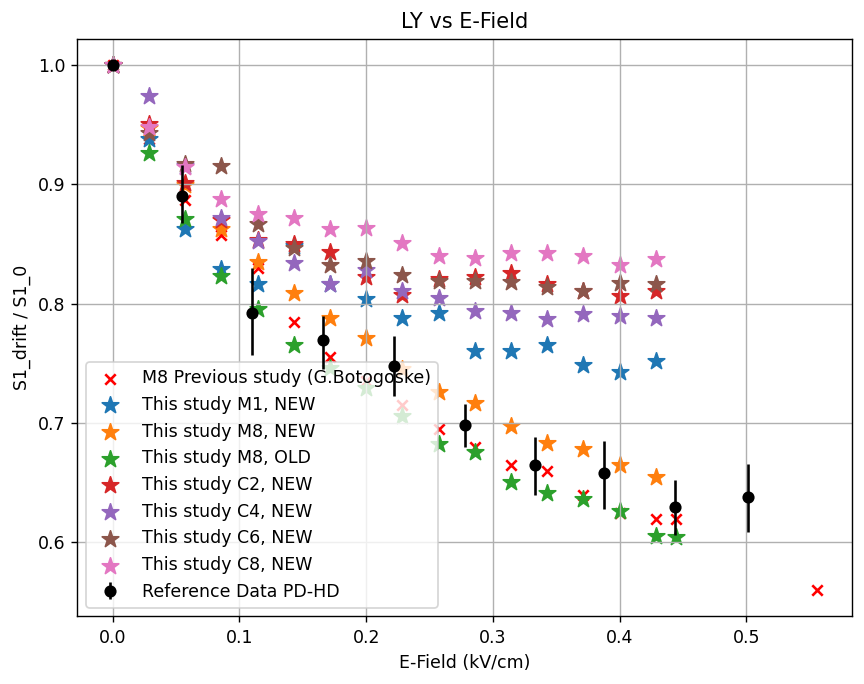

In [ ]:

study_results = []
for study in study_configs:
    efields, means = calculate_study(study["csv_suffix"], study["channels"])
    study_results.append({**study, "efields": efields, "means": means})
    print(f"{study['label']}: {len(means)} electric-field points")



plt.figure(dpi=125, figsize=(8, 6))

plt.scatter(
    efield_previous,
    relative_s1_previous,
    marker="x",
    color="red",
    label="M8 Previous study (G.Botogoske)",
)

for study in study_results:
    plt.scatter(
        study["efields"],
        study["means"],
        label=study["label"],
        marker="*",
        s=100,
    )
plt.errorbar(E, PD_HD_result, yerr=[PD_HD_err_low, PD_HD_err_high], color="black", label="Reference Data PD-HD", zorder=10, fmt='o')
plt.grid()
plt.legend()
plt.xlabel("E-Field (kV/cm)")
plt.ylabel("S1_drift / S1_0")
plt.title("LY vs E-Field")
plt.show()


